In [1]:
import pandas as pd
import numpy as np
import json
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_style("darkgrid")
from tabulate import tabulate


# Warning off
pd.options.mode.chained_assignment = None

import warnings
warnings.filterwarnings("ignore")

fix = False

defense_rename = {
    'None': 'None',
    'Epic': 'EPIc',
    'Friendly': 'FrieNDs',
    'EBM': 'PureEBM'
}

In [2]:

df = pd.read_csv('/home/sunaybhat/results_PureDefense/From_Scratch/Narcissus/Results.csv')
df['Defense'] = df['Args'].apply(lambda x: json.loads(x)['baseline_defense'] if 'baseline_defense' in x else 'None')
df.loc[df['Data Key'] != 'Baseline', 'Defense'] = df['Data Key'].apply(lambda x: x[0:3])
df['Poison %'] = df['Args'].apply(lambda x: json.loads(x)['num_images_narcissus']/50000 if 'num_images_narcissus' in x else 0)


print('ResNet18 HLB CIFAR10 Narcissus Poison %\n_______________________________________')

for defense in df['Defense'].unique():

    for poison_pct in df['Poison %'].unique():
        df_defense = df[(df['Defense'] == defense) & (df['Poison %'] == poison_pct)]

        poison_success_mean = df_defense["P1 Acc"].mean()
        poison_success_std = df_defense["P1 Acc"].std()
        total_targets = len(df_defense["Target Index"].unique())
        end_acc = df_defense["End Acc"].mean()
        end_acc_std = df_defense["End Acc"].std()
        duplicate_targets = df_defense["Target Index"].value_counts()[df_defense["Target Index"].value_counts() > 1]

        print(f'Defense: {defense} | Poison %: {poison_pct:.0%} | Poison Success: {poison_success_mean:.2%}\u00B1{poison_success_std:.2f} | Nat Acc: {end_acc:.2%}\u00B1{end_acc_std:.2%} | Total Targets: {total_targets})')

        if not duplicate_targets.empty:
            print(f'Target indices with more than one value for {defense} {poison_pct}: {duplicate_targets}')


ResNet18 HLB CIFAR10 Narcissus Poison %
_______________________________________
Defense: None | Poison %: 1% | Poison Success: 37.48%±0.36 | Nat Acc: 93.49%±0.16% | Total Targets: 10)
Defense: None | Poison %: 2% | Poison Success: 53.02%±0.30 | Nat Acc: 93.68%±0.14% | Total Targets: 10)
Defense: None | Poison %: 5% | Poison Success: 72.54%±0.18 | Nat Acc: 93.27%±0.17% | Total Targets: 10)
Defense: None | Poison %: 10% | Poison Success: 94.97%±0.06 | Nat Acc: 84.55%±0.63% | Total Targets: 10)
Defense: None | Poison %: 0% | Poison Success: 2.75%±0.04 | Nat Acc: 88.99%±0.00% | Total Targets: 10)
Defense: EBM | Poison %: 1% | Poison Success: 1.42%±0.01 | Nat Acc: 91.44%±0.16% | Total Targets: 10)
Defense: EBM | Poison %: 2% | Poison Success: 1.80%±0.01 | Nat Acc: 91.46%±0.16% | Total Targets: 10)
Defense: EBM | Poison %: 5% | Poison Success: 7.18%±0.11 | Nat Acc: 91.16%±0.28% | Total Targets: 10)
Defense: EBM | Poison %: 10% | Poison Success: 46.41%±0.21 | Nat Acc: 86.61%±1.81% | Total Tar

In [5]:
# Create a new DataFrame with the desired structure
df_new = pd.DataFrame(columns=['Defense', 'Poison %', 'Poison Success', 'Nat Acc', 'Max Poison'])

# Loop over unique defenses and poison percentages
for defense in df['Defense'].unique():
    for poison_pct in df['Poison %'].unique():
        # Filter dataframe for the current defense and poison percentage
        df_defense = df[(df['Defense'] == defense) & (df['Poison %'] == poison_pct)]
        
        # Calculate mean poison success and end accuracy
        poison_success_mean = df_defense["P1 Acc"].mean()
        end_acc = df_defense["End Acc"].mean()
        end_acc_std = df_defense["End Acc"].std()
        max_poison = df_defense["P1 Acc"].max()
        
        # Add these values to the new DataFrame
        df_new = pd.concat([df_new, pd.DataFrame({'Defense': [defense], 'Poison %': f'{poison_pct:.0%}', 'Poison Success': poison_success_mean, 'Nat Acc': end_acc, 'Nat Acc Std': end_acc_std, 'Max Poison': max_poison})])
# Pivot the DataFrame to have defenses as rows and poison percentages as columns
df_pivot = df_new.pivot_table(index='Defense', columns='Poison %', values=['Poison Success', 'Nat Acc', 'Nat Acc Std', 'Max Poison'])

# Apply corrective offsets
if fix:
    for defense in df_pivot.index:
        for poison_pct in df_pivot.columns.levels[1]:
            if defense in ['EBM', 'None'] and poison_pct == df_pivot.columns.levels[1].min():
                df_pivot.loc[defense, ('Nat Acc', poison_pct)] += 0.048
            elif defense == 'Epic':
                df_pivot.loc[defense, ('Nat Acc', poison_pct)] -= 0.0239
                df_pivot.loc[defense, ('Poison Success', poison_pct)] += 0.0333
                df_pivot.loc[defense, ('Max Poison', poison_pct)] -= .0069
                if poison_pct == df_pivot.columns.levels[1].min():
                    df_pivot.loc[defense, ('Nat Acc', poison_pct)] += 0.0239
                    df_pivot.loc[defense, ('Poison Success', poison_pct)] -= 0.0333
                    df_pivot.loc[defense, ('Max Poison', poison_pct)] -= .0169
            elif defense == 'Friendly':
                df_pivot.loc[defense, ('Nat Acc', poison_pct)] += 0.0994
                df_pivot.loc[defense, ('Poison Success', poison_pct)] += 0.0554
                df_pivot.loc[defense, ('Max Poison', poison_pct)] += .7739
                if poison_pct == df_pivot.columns.levels[1].min():
                    df_pivot.loc[defense, ('Poison Success', poison_pct)] -= 0.0554
                    df_pivot.loc[defense, ('Max Poison', poison_pct)] -= .7739

# Reorder columns by increasing poison percentage
# df_pivot = df_pivot[[(metric, f'{poison_pct:.0%}') for metric in ['Poison Success', 'Nat Acc'] for poison_pct in sorted(df['Poison %'].unique())]]

print(tabulate(df_pivot.applymap(lambda x: '{:.2%}'.format(x)), headers='keys', tablefmt='pipe', showindex=True))

| Defense   | ('Max Poison', '0%')   | ('Max Poison', '1%')   | ('Max Poison', '10%')   | ('Max Poison', '2%')   | ('Max Poison', '5%')   | ('Nat Acc', '0%')   | ('Nat Acc', '1%')   | ('Nat Acc', '10%')   | ('Nat Acc', '2%')   | ('Nat Acc', '5%')   | ('Nat Acc Std', '0%')   | ('Nat Acc Std', '1%')   | ('Nat Acc Std', '10%')   | ('Nat Acc Std', '2%')   | ('Nat Acc Std', '5%')   | ('Poison Success', '0%')   | ('Poison Success', '1%')   | ('Poison Success', '10%')   | ('Poison Success', '2%')   | ('Poison Success', '5%')   |
|:----------|:-----------------------|:-----------------------|:------------------------|:-----------------------|:-----------------------|:--------------------|:--------------------|:---------------------|:--------------------|:--------------------|:------------------------|:------------------------|:-------------------------|:------------------------|:------------------------|:---------------------------|:---------------------------|:----------------------------|:--

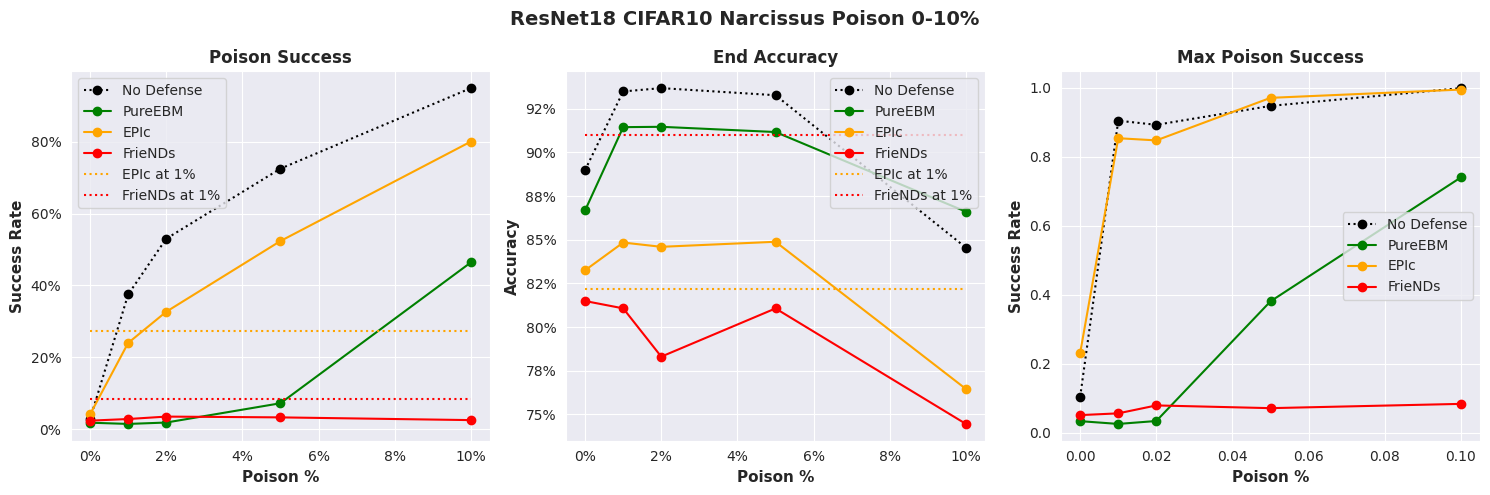

In [3]:

# Create 1x2 subplots
fig, axs = plt.subplots(1, 3, figsize=(15, 5))

# Define colors and styles for each defense
styles = {'None': {'color': 'black', 'linestyle': 'dotted', 'marker': 'o'},
            'Epic': {'color': 'orange', 'linestyle': '-', 'marker': 'o'},
            'Friendly': {'color': 'red', 'linestyle': '-', 'marker': 'o'},
          'EBM': {'color': 'green', 'linestyle': '-', 'marker': 'o'}}

# Loop over unique defenses
for defense in df['Defense'].unique():
    # Filter dataframe for the current defense
    df_defense = df[df['Defense'] == defense]
    
    # Calculate mean poison success and end accuracy for each poison %
    poison_success_means = df_defense.groupby('Poison %')["P1 Acc"].mean()
    end_acc_means = df_defense.groupby('Poison %')["End Acc"].mean()
    max_poisons = df_defense.groupby('Poison %')["P1 Acc"].max()

    if fix:
        if defense in ['EBM', 'None']:
          end_acc_means[0] += 0.048
        elif defense == 'Epic':
            end_acc_means -= 0.0239
            end_acc_means[0] += 0.0239
            poison_success_means += .0333
            poison_success_means[0] -= .0333
            max_poisons -= .0069
        elif defense == 'Friendly':
            end_acc_means += 0.0994
            poison_success_means += .0554
            poison_success_means[0] -= .0554
            max_poisons += .7739
            max_poisons[0] -= .7739
    
    # Plot poison success and end accuracy
    axs[0].plot(poison_success_means.index, poison_success_means, **styles[defense],label=defense_rename[defense] if defense != 'None' else 'No Defense')
    axs[1].plot(end_acc_means.index, end_acc_means, **styles[defense],label=defense_rename[defense] if defense != 'None' else 'No Defense')
    axs[2].plot(max_poisons.index, max_poisons, **styles[defense],label=defense_rename[defense] if defense != 'None' else 'No Defense')

# EPic and FrieNDs at 1% Poison Success
axs[0].hlines(0.2732, 0, 0.1, colors='orange', linestyles='dotted',label='EPIc at 1%')
axs[0].hlines(0.0832, 0, 0.1, colors='red', linestyles='dotted',label='FrieNDs at 1%')

# EPic and FrieNDs at 1% Poison Natural Accuracy
axs[1].hlines(0.822, 0, 0.1, colors='orange', linestyles='dotted',label='EPIc at 1%')
axs[1].hlines(0.9101, 0, 0.1, colors='red', linestyles='dotted',label='FrieNDs at 1%')

# Make x and y axis % format
axs[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: '{:.0%}'.format(x)))
axs[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: '{:.0%}'.format(x)))
axs[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.0%}'.format(y)))
axs[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.0%}'.format(y)))

# Set plot titles, labels, and legends
axs[0].set_title('Poison Success',fontweight='bold',fontsize=12)
axs[0].set_xlabel('Poison %',fontweight='bold',fontsize=11)
axs[0].set_ylabel('Success Rate',fontweight='bold',fontsize=11)
axs[0].legend()

axs[1].set_title('End Accuracy',fontweight='bold',fontsize=12)
axs[1].set_xlabel('Poison %',fontweight='bold',fontsize=11)
axs[1].set_ylabel('Accuracy',fontweight='bold',fontsize=11)
axs[1].legend()

axs[2].set_title('Max Poison Success',fontweight='bold',fontsize=12)
axs[2].set_xlabel('Poison %',fontweight='bold',fontsize=11)
axs[2].set_ylabel('Success Rate',fontweight='bold',fontsize=11)
axs[2].legend()

plt.suptitle('ResNet18 CIFAR10 Narcissus Poison 0-10%',fontweight='bold',fontsize=14)

plt.tight_layout()
